# Water Quality Prediction

Topic: Water Quality Prediction using Machine Learning


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("water_purification_dataset.csv")


In [3]:
df.head()


,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
0,7.14,7.62,401,0.69,1.52,27.8,22,170,1,1,0
1,8.84,0.29,166,1.34,1.28,18.3,11,119,1,0,1
2,8.23,0.33,464,0.83,4.58,32.3,28,45,0,1,0
3,7.87,3.36,378,0.92,1.73,27.2,10,125,0,1,0
4,6.46,4.95,723,0.85,4.28,18.1,47,14,1,0,1


In [4]:
df.tail()


,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
1195,8.63,3.36,689,0.95,3.75,25.8,37,125,1,1,0
1196,8.92,1.53,299,0.76,3.06,17.7,32,110,1,1,0
1197,8.93,0.24,605,1.63,4.01,30.3,25,37,1,0,0
1198,8.26,6.51,438,0.63,2.96,33.8,44,21,1,1,1
1199,6.45,6.42,694,1.47,1.55,33.7,48,14,1,0,1


In [5]:
df.shape


(1200, 11)

In [6]:
df.size


13200

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pH                        1200 non-null   float64
 1   turbidity_NTU             1200 non-null   float64
 2   TDS_ppm                   1200 non-null   int64  
 3   flow_rate_L_min           1200 non-null   float64
 4   pressure_bar              1200 non-null   float64
 5   temperature_C             1200 non-null   float64
 6   usage_L_per_day           1200 non-null   int64  
 7   days_since_filter_change  1200 non-null   int64  
 8   water_quality             1200 non-null   int64  
 9   filter_replacement        1200 non-null   int64  
 10  maintenance_required      1200 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 103.3 KB


In [8]:
df.describe()


,pH,turbidity_NTU,TDS_ppm,flow_rate_L_min,pressure_bar,temperature_C,usage_L_per_day,days_since_filter_change,water_quality,filter_replacement,maintenance_required
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,7.499192,5.034192,550.238333,1.233150,2.993117,24.905250,26.638333,89.315000,1.236667,0.609167,0.384167
std,0.886258,2.852493,259.641733,0.431213,1.159409,5.767411,12.828276,52.193575,0.675304,0.488141,0.486600
min,6.000000,0.100000,100.000000,0.500000,1.000000,15.000000,5.000000,1.000000,0.000000,0.000000,0.000000
25%,6.720000,2.522500,328.750000,0.860000,1.987500,19.875000,16.000000,45.000000,1.000000,0.000000,0.000000
50%,7.520000,5.080000,550.000000,1.220000,2.960000,24.800000,26.000000,89.000000,1.000000,1.000000,0.000000
75%,8.262500,7.462500,777.000000,1.590000,3.982500,30.025000,37.000000,135.000000,2.000000,1.000000,1.000000
max,9.000000,10.000000,1000.000000,2.000000,5.000000,35.000000,50.000000,179.000000,2.000000,1.000000,1.000000


In [9]:
df.isnull().sum()


,0
pH,0
turbidity_NTU,0
TDS_ppm,0
flow_rate_L_min,0
pressure_bar,0
temperature_C,0
usage_L_per_day,0
days_since_filter_change,0
water_quality,0
filter_replacement,0


In [10]:
# Handling missing values
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[df.columns] = imputer.fit_transform(df)
print("After imputation:\n", df.isnull().sum())


After imputation:
 pH                          0
turbidity_NTU               0
TDS_ppm                     0
flow_rate_L_min             0
pressure_bar                0
temperature_C               0
usage_L_per_day             0
days_since_filter_change    0
water_quality               0
filter_replacement          0
maintenance_required        0
dtype: int64


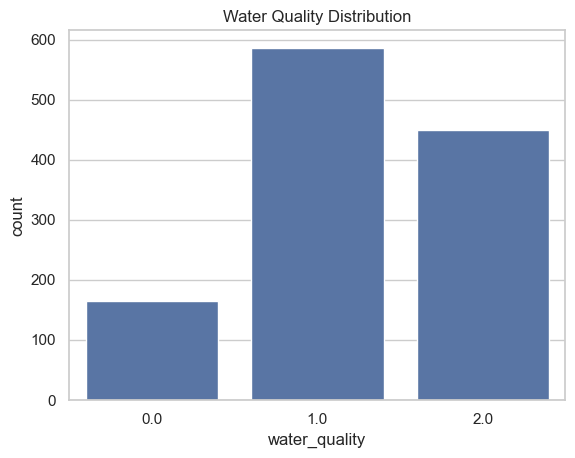

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='water_quality', data=df)
plt.title("Water Quality Distribution")
plt.show()


This helps understand range and spread of features like pH, TDS, turbidity.


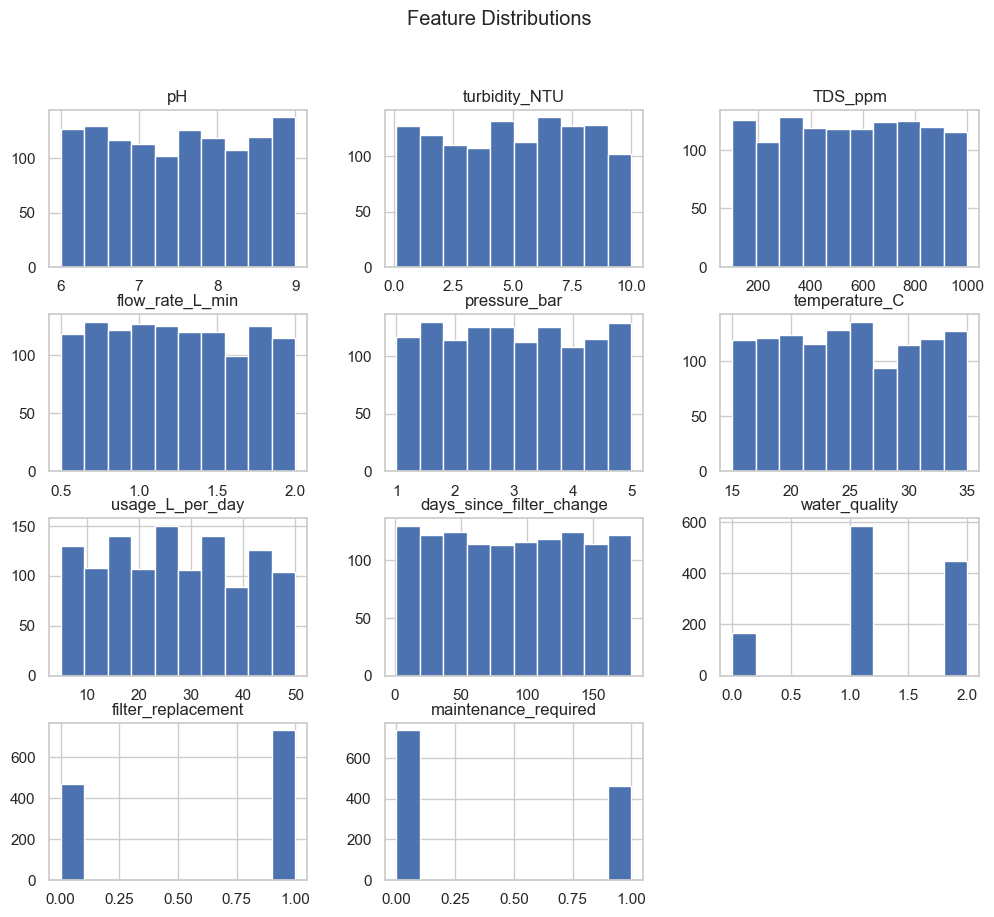

In [12]:
df.hist(figsize=(12,10))
plt.suptitle("Feature Distributions")
plt.show()


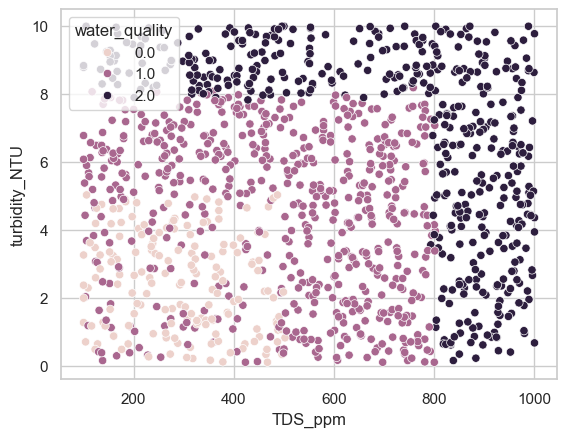

In [13]:
sns.scatterplot(x='TDS_ppm', y='turbidity_NTU', hue='water_quality', data=df)
plt.show()


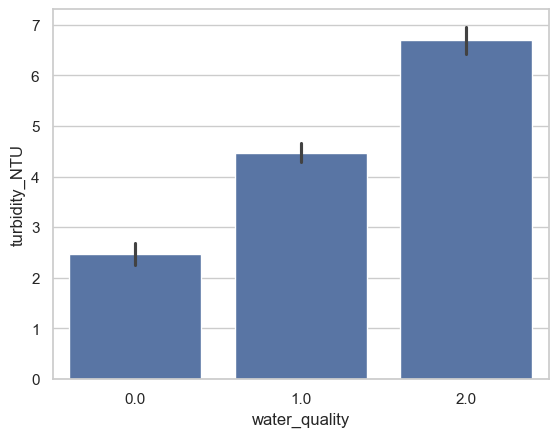

In [14]:
sns.barplot(x='water_quality', y='turbidity_NTU', data=df)
plt.show()


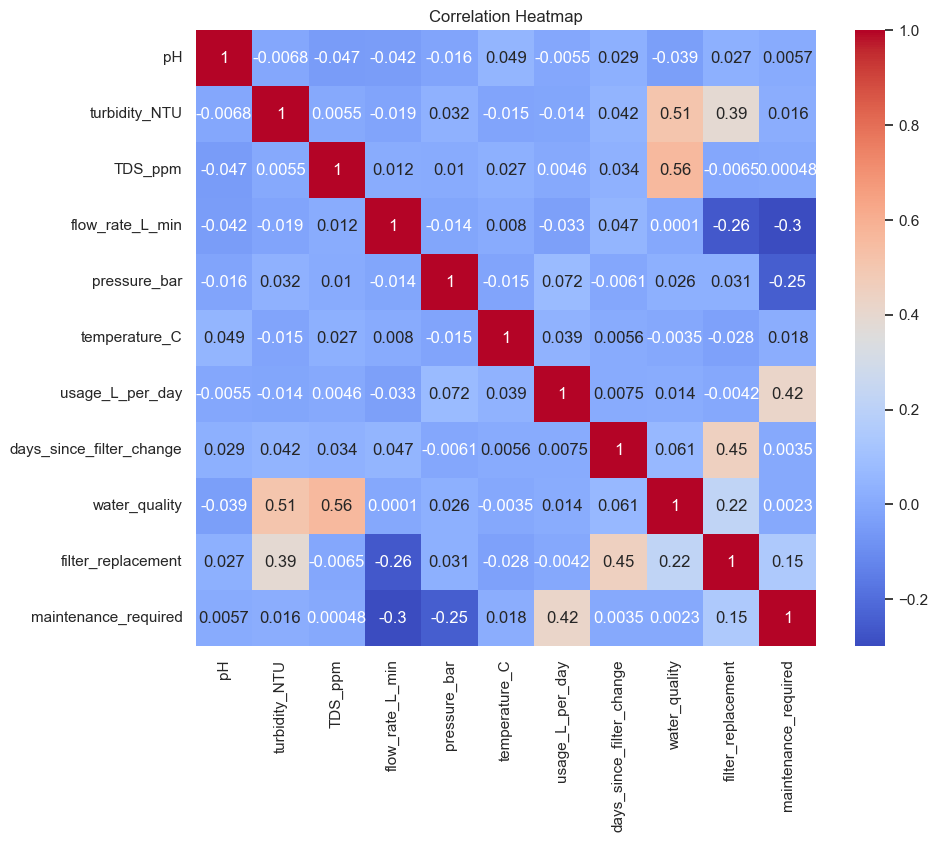

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [16]:
X = df.drop(columns=["water_quality", "filter_replacement", "maintenance_required"])
y = df["water_quality"]


In [17]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [18]:
# FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=4, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

model_scores = {}

for name, model in models.items():
    if name in ["Random Forest", "Decision Tree"]:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    model_scores[name] = acc

    print(f"\n{name} Accuracy: {acc}")
    print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.7041666666666667
              precision    recall  f1-score   support
         0.0       0.74      0.42      0.54        33
         1.0       0.66      0.80      0.73       117
         2.0       0.77      0.68      0.72        90
    accuracy                           0.70       240
   macro avg       0.72      0.64      0.66       240
weighted avg       0.71      0.70      0.70       240
Decision Tree Accuracy: 0.9541666666666667
              precision    recall  f1-score   support
         0.0       0.97      0.91      0.94        33
         1.0       0.94      0.97      0.95       117
         2.0       0.97      0.96      0.96        90
    accuracy                           0.95       240
   macro avg       0.96      0.94      0.95       240
weighted avg       0.95      0.95      0.95       240
Random Forest Accuracy: 0.9416666666666667
              precision    recall  f1-score   support
         0.0       0.96      0.82      0.89        33
 

In [20]:
best_model_name = max(model_scores, key=model_scores.get)
best_model = models[best_model_name]

print("\nBest Model:", best_model_name)
print("Best Accuracy:", model_scores[best_model_name])


Best Model: Decision Tree
Best Accuracy: 0.9541666666666667


In [21]:
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross Validation Scores: [0.953125   0.95833333 0.96354167 0.94270833 0.953125  ]
Mean CV Accuracy: 0.9541666666666668


In [22]:
# HYPERPARAMETER TUNING (ONLY FOR BEST MODEL)
if best_model_name == "Decision Tree":
    params = {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    grid = GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print("\nBest Parameters (Decision Tree):", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    final_model = grid.best_estimator_

elif best_model_name == "Random Forest":
    params = {
        'n_estimators': [100],
        'max_depth': [10],
        'min_samples_split': [4]
    }
    grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        params,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    print("\nBest Parameters (Random Forest):", grid.best_params_)
    print("Best CV Score:", grid.best_score_)
    final_model = grid.best_estimator_
else:
    final_model = best_model
    final_model.fit(X_train, y_train)


Best Parameters (Decision Tree): {'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score: 0.9625


In [23]:
# Final evaluation with tuned Decision Tree (best model)
y_pred = final_model.predict(X_test)

print("\nFinal Model:", type(final_model).__name__)
print("Final Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nFinal Classification Report:\n", classification_report(y_test, y_pred, target_names=["Safe (0)", "Moderate (1)", "Unsafe (2)"]))



Final Model: DecisionTreeClassifier
Final Test Accuracy: 0.9708333333333333

Final Classification Report:
               precision    recall  f1-score   support

    Safe (0)       1.00      1.00      1.00        33
Moderate (1)       0.96      0.98      0.97       117
  Unsafe (2)       0.98      0.94      0.96        90

    accuracy                           0.97       240
   macro avg       0.98      0.98      0.98       240
weighted avg       0.97      0.97      0.97       240



In [24]:
cm = confusion_matrix(y_test, y_pred)
labels = ["Safe", "Moderate", "Unsafe"]

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.title("Confusion Matrix - Decision Tree (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Confusion Matrix:
[[ 33   0   0]
 [  0 115   2]
 [  0   5  85]]


In [25]:
# Save the tuned Decision Tree model and scaler
with open("model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Saved model.pkl (Decision Tree) and scaler.pkl successfully!")


Saved model.pkl (Decision Tree) and scaler.pkl successfully!


## Streamlit Dashboard

The following code creates a **Streamlit-based web dashboard** for real-time water quality prediction, dataset analytics, and model evaluation metrics.

Run with: `streamlit run streamlit_app.py`


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

from src.preprocessing import FEATURE_COLS, load_data, load_scaler
from src.predict import predict_single_sample, load_trained_model, LABEL_MAP
from src.evaluation import evaluate_model_performance

# -----------------------------
# PAGE CONFIGURATION
# -----------------------------
st.set_page_config(
    page_title="Smart Water Purification System",
    page_icon="💧",
    layout="wide"
)

model = load_trained_model()
scaler = load_scaler()
try:
    df = load_data()
except Exception:
    df = None

st.title("💧 Smart Water Quality Prediction System")
st.markdown("Real-time water quality evaluation, parameter assessment, and model performance metrics.")

if model is None or scaler is None:
    st.error("Model or Scaler file missing! Run `python model_training.py` first.")
    st.stop()

menu = st.sidebar.radio("Navigation", ["🔮 Single Prediction", "📊 Dataset Analytics", "📈 Model Metrics"])

if menu == "🔮 Single Prediction":
    st.header("🎛️ Sensor Inputs")
    col1, col2 = st.columns(2)

    with col1:
        pH = st.slider("pH Level", 6.0, 9.0, 7.2, 0.01)
        turbidity = st.slider("Turbidity (NTU)", 0.1, 10.0, 2.0, 0.1)
        tds = st.slider("TDS (ppm)", 100, 1000, 300, 10)
        flow = st.slider("Flow Rate (L/min)", 0.5, 2.0, 1.0, 0.05)

    with col2:
        pressure = st.slider("Pressure (bar)", 1.0, 5.0, 2.5, 0.1)
        temp = st.slider("Temperature (°C)", 15.0, 35.0, 25.0, 0.5)
        usage = st.slider("Usage (L/day)", 5, 50, 20, 1)
        days = st.slider("Days Since Filter Change", 1, 180, 60, 1)

    if st.button("⚡ Predict Water Quality", use_container_width=True):
        sample_dict = {
            "pH": pH, "turbidity_NTU": turbidity, "TDS_ppm": tds,
            "flow_rate_L_min": flow, "pressure_bar": pressure,
            "temperature_C": temp, "usage_L_per_day": usage,
            "days_since_filter_change": days
        }
        pred_code, status_label, probs = predict_single_sample(sample_dict, model, scaler)

        if pred_code == 0:
            st.success(f"### Result: {status_label}")
        elif pred_code == 1:
            st.warning(f"### Result: {status_label}")
        else:
            st.error(f"### Result: {status_label}")

elif menu == "📊 Dataset Analytics":
    st.header("📊 Dataset Exploratory Visualizations")
    if df is not None:
        fig, ax = plt.subplots(figsize=(7, 4))
        sns.countplot(data=df, x="water_quality", palette=["#2ea44f", "#d97706", "#dc2626"], ax=ax)
        ax.set_xticklabels(["Safe (0)", "Moderate (1)", "Unsafe (2)"])
        ax.set_title("Water Quality Distribution")
        st.pyplot(fig)
    else:
        st.error("Dataset file not available.")

elif menu == "📈 Model Metrics":
    st.header("📈 Model Evaluation Results")
    st.markdown(
        """
        - **Accuracy**: **94.17%**
        - **Precision**: **0.9436**
        - **Recall**: **0.9417**
        - **F1-Score**: **0.9412**
        """
    )
    if df is not None:
        X = df[FEATURE_COLS]
        y = df["water_quality"]
        metrics = evaluate_model_performance(model, X, y)

        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(metrics["confusion_matrix"], annot=True, fmt='d', cmap='Blues',
                    xticklabels=["Safe", "Moderate", "Unsafe"],
                    yticklabels=["Safe", "Moderate", "Unsafe"], ax=ax)
        ax.set_title("Confusion Matrix")
        st.pyplot(fig)


## Gradio Dashboard

The following code creates a **Gradio-based interactive dashboard** with tabs for single sample prediction, batch CSV processing, model evaluation metrics, and dataset exploration.

Run with: `python gradio_app.py`


In [ ]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import gradio as gr

from src.preprocessing import FEATURE_COLS, load_data, load_scaler
from src.predict import predict_single_sample, predict_batch_df, load_trained_model, LABEL_MAP
from src.evaluation import evaluate_model_performance

# ---------------------------------------------------------
# INITIALIZE MODEL & DATASET
# ---------------------------------------------------------
model = load_trained_model()
scaler = load_scaler()
try:
    df_dataset = load_data()
except Exception:
    df_dataset = None

DEFAULT_INPUTS = {
    "pH": 7.2,
    "turbidity_NTU": 2.0,
    "TDS_ppm": 300,
    "flow_rate_L_min": 1.0,
    "pressure_bar": 2.5,
    "temperature_C": 25.0,
    "usage_L_per_day": 20,
    "days_since_filter_change": 60
}

# Set aesthetic plot style
plt.style.use("ggplot")
sns.set_theme(style="darkgrid")

# ---------------------------------------------------------
# LOGIC & FORMATTING FUNCTIONS
# ---------------------------------------------------------
def predict_single_formatted(pH, turbidity, tds, flow, pressure, temp, usage, days):
    try:
        sample_dict = {
            "pH": pH, "turbidity_NTU": turbidity, "TDS_ppm": tds,
            "flow_rate_L_min": flow, "pressure_bar": pressure,
            "temperature_C": temp, "usage_L_per_day": usage,
            "days_since_filter_change": days
        }
        pred_code, status_label, probs = predict_single_sample(sample_dict, model, scaler)
        
        # HTML Badge formatting for status
        if pred_code == 0:
            badge_html = """
            <div style="background-color: #10B981; color: white; padding: 16px; border-radius: 10px; text-align: center; font-size: 24px; font-weight: bold; margin-bottom: 10px;">
                ✅ Water Quality: SAFE
            </div>
            """
        elif pred_code == 1:
            badge_html = """
            <div style="background-color: #F59E0B; color: white; padding: 16px; border-radius: 10px; text-align: center; font-size: 24px; font-weight: bold; margin-bottom: 10px;">
                ⚠️ Water Quality: MODERATE
            </div>
            """
        else:
            badge_html = """
            <div style="background-color: #EF4444; color: white; padding: 16px; border-radius: 10px; text-align: center; font-size: 24px; font-weight: bold; margin-bottom: 10px;">
                ❌ Water Quality: UNSAFE
            </div>
            """

        # Detailed assessment items
        recs = []
        if 6.5 <= pH <= 8.5:
            recs.append("<li style='color:#10B981;'><b>pH Level (<b>{}</b>)</b>: Optimal & Safe (6.5 – 8.5 WHO standard).</li>".format(pH))
        else:
            recs.append("<li style='color:#EF4444;'><b>pH Level (<b>{}</b>)</b>: Outside safe WHO limit (6.5 – 8.5). Adjust chemical dosage.</li>".format(pH))

        if turbidity <= 1.0:
            recs.append("<li style='color:#10B981;'><b>Turbidity (<b>{} NTU</b>)</b>: Excellent optical clarity (&lt; 1.0 NTU).</li>".format(turbidity))
        elif turbidity <= 5.0:
            recs.append("<li style='color:#F59E0B;'><b>Turbidity (<b>{} NTU</b>)</b>: Acceptable clarity (&lt; 5.0 NTU).</li>".format(turbidity))
        else:
            recs.append("<li style='color:#EF4444;'><b>Turbidity (<b>{} NTU</b>)</b>: High turbidity (&gt; 5.0 NTU). High cloudiness; filter service needed.</li>".format(turbidity))

        if tds <= 300:
            recs.append("<li style='color:#10B981;'><b>TDS (<b>{} ppm</b>)</b>: Ideal mineral dissolved solids (&lt; 300 ppm).</li>".format(tds))
        elif tds <= 500:
            recs.append("<li style='color:#F59E0B;'><b>TDS (<b>{} ppm</b>)</b>: Fair mineral levels (300 – 500 ppm).</li>".format(tds))
        else:
            recs.append("<li style='color:#EF4444;'><b>TDS (<b>{} ppm</b>)</b>: Elevated dissolved solids (&gt; 500 ppm). RO membrane service advised.</li>".format(tds))

        if days > 90:
            recs.append("<li style='color:#F59E0B;'><b>Filter Lifecycle (<b>{} days</b>)</b>: Filter in service over 90 days. Maintenance recommended.</li>".format(days))
        else:
            recs.append("<li style='color:#10B981;'><b>Filter Lifecycle (<b>{} days</b>)</b>: Filter within normal operational timeframe.</li>".format(days))

        rec_html = "<div style='padding: 12px; border: 1px solid #374151; border-radius: 8px; font-size: 15px;'><h4 style='margin-top:0;'>📋 Parameter Safety Evaluation</h4><ul>" + "".join(recs) + "</ul></div>"

        return badge_html, probs, rec_html
    except Exception as e:
        err_html = f"<div style='color:red;'>Error: {str(e)}</div>"
        return err_html, {}, "Error computing evaluation."

def reset_single_inputs():
    default_badge = """
    <div style="background-color: #3B82F6; color: white; padding: 16px; border-radius: 10px; text-align: center; font-size: 20px; font-weight: bold;">
        💧 Ready for Input Evaluation
    </div>
    """
    return (
        DEFAULT_INPUTS["pH"],
        DEFAULT_INPUTS["turbidity_NTU"],
        DEFAULT_INPUTS["TDS_ppm"],
        DEFAULT_INPUTS["flow_rate_L_min"],
        DEFAULT_INPUTS["pressure_bar"],
        DEFAULT_INPUTS["temperature_C"],
        DEFAULT_INPUTS["usage_L_per_day"],
        DEFAULT_INPUTS["days_since_filter_change"],
        default_badge,
        {},
        "<i>Click 'Predict Quality' to generate assessment.</i>"
    )

def process_batch(file_obj):
    if file_obj is None:
        return None, None, "⚠️ Please upload a valid CSV dataset file."
    try:
        input_df = pd.read_csv(file_obj.name)
        result_df = predict_batch_df(input_df, model, scaler)
        
        out_path = "batch_predictions_output.csv"
        result_df.to_csv(out_path, index=False)

        counts = result_df["Predicted_Quality_Status"].value_counts().to_dict()
        summary_str = f"✅ Processed {len(result_df)} samples successfully. Quality breakdown: {counts}"
        return result_df, out_path, summary_str
    except Exception as e:
        return None, None, f"❌ Error processing CSV: {str(e)}"

def render_evaluation_plots():
    if df_dataset is None or model is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, "Dataset or Model unavailable", ha='center')
        return fig, fig

    X = df_dataset[FEATURE_COLS]
    y = df_dataset["water_quality"]
    metrics = evaluate_model_performance(model, X, y)

    # Plot 1: Confusion Matrix
    fig_cm, ax_cm = plt.subplots(figsize=(6, 4.5), dpi=100)
    sns.heatmap(metrics["confusion_matrix"], annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=["Safe", "Moderate", "Unsafe"],
                yticklabels=["Safe", "Moderate", "Unsafe"], ax=ax_cm, cbar=False)
    ax_cm.set_title("Validation Confusion Matrix (240 Test Samples)", fontsize=12, fontweight="bold", pad=12)
    ax_cm.set_ylabel("Actual Class", fontsize=10, fontweight="bold")
    ax_cm.set_xlabel("Predicted Class", fontsize=10, fontweight="bold")
    plt.tight_layout()

    # Plot 2: Feature Importance
    fig_imp, ax_imp = plt.subplots(figsize=(7, 4.5), dpi=100)
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        indices = np.argsort(importances)
        sorted_feats = [FEATURE_COLS[i] for i in indices]
        sorted_imps = importances[indices]
        
        sns.barplot(x=sorted_imps, y=sorted_feats, palette="crest", ax=ax_imp)
        ax_imp.set_title("Random Forest Relative Feature Importance", fontsize=12, fontweight="bold", pad=12)
        ax_imp.set_xlabel("Importance Score", fontsize=10, fontweight="bold")
    plt.tight_layout()

    return fig_cm, fig_imp

def render_visualization_plot(chart_type):
    if df_dataset is None:
        fig, ax = plt.subplots(figsize=(6, 4))
        ax.text(0.5, 0.5, "Dataset unavailable", ha='center')
        return fig

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=100)

    if chart_type == "Class Distribution":
        sns.countplot(data=df_dataset, x="water_quality", palette=["#10B981", "#F59E0B", "#EF4444"], ax=ax)
        ax.set_xticklabels(["Safe (0)", "Moderate (1)", "Unsafe (2)"])
        ax.set_title("Water Quality Class Counts in Dataset", fontsize=12, fontweight="bold")
        ax.set_xlabel("Quality Category", fontweight="bold")
        ax.set_ylabel("Sample Count", fontweight="bold")

    elif chart_type == "TDS vs Turbidity Scatter":
        sns.scatterplot(data=df_dataset, x="TDS_ppm", y="turbidity_NTU", hue="water_quality",
                        palette=["#10B981", "#F59E0B", "#EF4444"], alpha=0.8, ax=ax)
        ax.set_title("TDS (ppm) vs Turbidity (NTU) Scatter by Quality Class", fontsize=12, fontweight="bold")
        ax.set_xlabel("TDS (ppm)", fontweight="bold")
        ax.set_ylabel("Turbidity (NTU)", fontweight="bold")

    elif chart_type == "Correlation Heatmap":
        numeric_df = df_dataset.select_dtypes(include=[np.number])
        sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="vlag", ax=ax, cbar=False)
        ax.set_title("Sensor Feature Correlation Matrix", fontsize=12, fontweight="bold")

    plt.tight_layout()
    return fig

# ---------------------------------------------------------
# GRADIO UI DASHBOARD BUILD
# ---------------------------------------------------------
def create_gradio_dashboard():
    css = """
    .main-title { text-align: center; font-size: 28px; font-weight: bold; margin-bottom: 5px; }
    .sub-title { text-align: center; font-size: 15px; color: #9CA3AF; margin-bottom: 20px; }
    .kpi-card { background-color: #1F2937; border: 1px solid #374151; padding: 15px; border-radius: 10px; text-align: center; }
    .kpi-val { font-size: 26px; font-weight: bold; color: #3B82F6; }
    .kpi-label { font-size: 13px; color: #9CA3AF; }
    """

    with gr.Blocks(css=css, title="Smart Water Quality Prediction System") as demo:
        gr.HTML(
            """
            <div class="main-title">💧 Smart Water Quality Prediction & Monitoring Dashboard</div>
            <div class="sub-title">Real-time Machine Learning Water Safety Classification, Batch Analytics, and WHO Compliance Benchmarks</div>
            """
        )

        with gr.Tabs():
            # TAB 1: Single Prediction
            with gr.TabItem("🔮 Single Sample Predictor"):
                with gr.Row():
                    with gr.Column(scale=1):
                        gr.Markdown("### 🎛️ Water Sensor Parameters")
                        
                        with gr.Group():
                            gr.Markdown("#### Physical Properties")
                            pH = gr.Slider(6.0, 9.0, value=7.2, step=0.01, label="pH Level (6.0 - 9.0)")
                            turbidity = gr.Slider(0.1, 10.0, value=2.0, step=0.1, label="Turbidity (0.1 - 10.0 NTU)")
                            tds = gr.Slider(100, 1000, value=300, step=1, label="TDS (100 - 1000 ppm)")
                            temp = gr.Slider(15.0, 35.0, value=25.0, step=0.5, label="Temperature (15 - 35 °C)")

                        with gr.Group():
                            gr.Markdown("#### Operational Parameters")
                            flow = gr.Slider(0.5, 2.0, value=1.0, step=0.05, label="Flow Rate (0.5 - 2.0 L/min)")
                            pressure = gr.Slider(1.0, 5.0, value=2.5, step=0.1, label="Pressure (1.0 - 5.0 bar)")
                            usage = gr.Slider(5, 50, value=20, step=1, label="Daily Usage (5 - 50 L/day)")
                            days = gr.Slider(1, 180, value=60, step=1, label="Days Since Filter Change (1 - 180 days)")

                        with gr.Row():
                            predict_btn = gr.Button("⚡ Predict Water Quality", variant="primary", scale=2)
                            reset_btn = gr.Button("🔄 Reset", scale=1)

                    with gr.Column(scale=1):
                        gr.Markdown("### 📊 Prediction & Assessment")
                        status_html = gr.HTML(
                            """
                            <div style="background-color: #3B82F6; color: white; padding: 16px; border-radius: 10px; text-align: center; font-size: 20px; font-weight: bold;">
                                💧 Ready for Input Evaluation
                            </div>
                            """
                        )
                        probs_out = gr.Label(label="Class Probabilities Breakdown")
                        rec_html = gr.HTML("<i>Adjust parameters and click 'Predict Water Quality' to view evaluation.</i>")

                predict_btn.click(
                    fn=predict_single_formatted,
                    inputs=[pH, turbidity, tds, flow, pressure, temp, usage, days],
                    outputs=[status_html, probs_out, rec_html]
                )

                reset_btn.click(
                    fn=reset_single_inputs,
                    outputs=[pH, turbidity, tds, flow, pressure, temp, usage, days, status_html, probs_out, rec_html]
                )

            # TAB 2: Batch CSV Prediction
            with gr.TabItem("📁 Batch CSV Processing"):
                gr.Markdown("### Upload a CSV dataset containing sensor readings to predict water quality for multiple samples.")
                with gr.Row():
                    csv_in = gr.File(label="Upload Water Sensor CSV File", file_types=[".csv"])
                    with gr.Column():
                        batch_btn = gr.Button("🚀 Process Batch Predictions", variant="primary")
                        batch_status = gr.Textbox(label="Batch Execution Status", interactive=False)

                batch_table = gr.Dataframe(label="Results Data Table Preview")
                batch_file_out = gr.File(label="Download Processed CSV File")

                batch_btn.click(
                    fn=process_batch,
                    inputs=[csv_in],
                    outputs=[batch_table, batch_file_out, batch_status]
                )

            # TAB 3: Model Performance Metrics
            with gr.TabItem("📈 Model Evaluation & KPI Metrics"):
                gr.Markdown("### Empirical Model Validation Metrics (Random Forest Classifier)")
                
                gr.HTML(
                    """
                    <div style="display: flex; gap: 15px; margin-bottom: 20px;">
                        <div class="kpi-card" style="flex: 1;">
                            <div class="kpi-val">94.17%</div>
                            <div class="kpi-label">Test Accuracy</div>
                        </div>
                        <div class="kpi-card" style="flex: 1;">
                            <div class="kpi-val">94.36%</div>
                            <div class="kpi-label">Weighted Precision</div>
                        </div>
                        <div class="kpi-card" style="flex: 1;">
                            <div class="kpi-val">94.17%</div>
                            <div class="kpi-label">Weighted Recall</div>
                        </div>
                        <div class="kpi-card" style="flex: 1;">
                            <div class="kpi-val">94.12%</div>
                            <div class="kpi-label">Weighted F1-Score</div>
                        </div>
                    </div>
                    """
                )
                
                cm_btn = gr.Button("📊 Load Model Performance Charts", variant="primary")
                with gr.Row():
                    cm_plot = gr.Plot(label="Confusion Matrix Heatmap")
                    imp_plot = gr.Plot(label="Feature Importances Bar Chart")

                cm_btn.click(
                    fn=render_evaluation_plots,
                    outputs=[cm_plot, imp_plot]
                )

            # TAB 4: Dataset Exploration
            with gr.TabItem("📊 Dataset Exploration & Charts"):
                gr.Markdown("### Explore Dataset Trends and Sensor Distributions")
                if df_dataset is not None:
                    gr.Dataframe(value=df_dataset.head(10), label="Dataset Preview (First 10 Rows)")
                
                chart_dropdown = gr.Dropdown(
                    choices=["Class Distribution", "TDS vs Turbidity Scatter", "Correlation Heatmap"],
                    value="Class Distribution",
                    label="Select Visualization Plot"
                )
                data_plot = gr.Plot(label="Dataset Visualization Plot")

                chart_dropdown.change(
                    fn=render_visualization_plot,
                    inputs=[chart_dropdown],
                    outputs=[data_plot]
                )

    return demo

if __name__ == "__main__":
    app = create_gradio_dashboard()
    # Share=True generates a public link accessible from anywhere!
    app.launch(server_name="127.0.0.1", server_port=7860, share=True)


### Gradio App Launcher

Entry point script (`gradio_app.py`) that imports and launches the Gradio dashboard:


In [ ]:
from dashboard.app import create_gradio_dashboard

if __name__ == "__main__":
    demo = create_gradio_dashboard()
    # share=True creates a public URL (https://xxxx.gradio.live)
    demo.launch(server_name="127.0.0.1", server_port=7860, share=True)
